In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv(r"C:\Users\tanay\OneDrive\Desktop\datasets\Naive-Bayes-Classification-Data.csv")
df

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1
...,...,...,...
990,45,87,0
991,40,83,0
992,40,83,0
993,40,60,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   glucose        995 non-null    int64
 1   bloodpressure  995 non-null    int64
 2   diabetes       995 non-null    int64
dtypes: int64(3)
memory usage: 23.4 KB


In [7]:
df.describe()

,glucose,bloodpressure,diabetes
count,995.000000,995.000000,995.000000
mean,44.306533,79.184925,0.500503
std,6.707567,9.340204,0.500251
min,20.000000,50.000000,0.000000
25%,40.000000,72.000000,0.000000
50%,45.000000,80.000000,1.000000
75%,50.000000,87.000000,1.000000
max,70.000000,100.000000,1.000000


In [8]:
df.isnull().sum()

glucose          0
bloodpressure    0
diabetes         0
dtype: int64

In [9]:
x = df.drop("diabetes",axis=1)
x.shape

(995, 2)

In [20]:
y = df["diabetes"]
y.shape

(995,)

In [11]:
x_train,x_test,y_train,y_test= train_test_split(x,y,random_state=42,test_size=0.2)
sc=StandardScaler()

In [13]:
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [15]:
y.value_counts()

diabetes
1    498
0    497
Name: count, dtype: int64

In [16]:
gnb = GaussianNB()
gnb.fit(x_train_scaled,y_train)
y_pred = gnb.predict(x_test_scaled)
y_pred

array([1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0])

In [17]:
print("Precision Score: ",precision_score(y_test,y_pred)) 
print("Recall Score: ",recall_score(y_test,y_pred))
print("Accuracy: ",accuracy_score(y_test,y_pred))


Precision Score:  0.9339622641509434
Recall Score:  0.9339622641509434
Accuracy:  0.9296482412060302


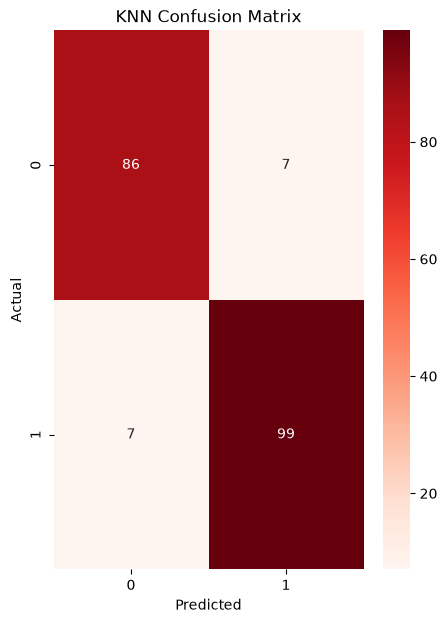

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,7))
sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Reds'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()